# Predict, then Optimize

**cvxpylayers + Moreau as a differentiable PyTorch layer** — end-to-end learning through a convex optimization solver.

This notebook demonstrates:
- Embedding a **batched** differentiable LP solver as a layer inside a neural network via `cvxpylayers`
- End-to-end training via backpropagation through the solver on **GPU**
- Comparison with a two-stage (predict-then-optimize) baseline
- Decision-focused learning on shortest path routing

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import sparse
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import cvxpy as cp
import moreau
from cvxpylayers.torch import CvxpyLayer

from utils.style import set_moreau_style, set_moreau_dark_style, MOREAU_COLORS
from utils.animation import fig_to_pil, save_gif, display_gif

set_moreau_style()
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Problem: Shortest Path with Side Information

A vehicle must navigate a 20×20 grid from the top-left to the bottom-right.
Edges go **right** and **down** only. The true edge costs depend on observable
context features, but the mapping from features to costs is unknown.

We formulate the shortest path as a **regularized LP**:

$$\min_f \; q^\top f + \frac{\varepsilon}{2} \|f\|^2 \quad \text{s.t.} \quad Af = d, \; f \geq 0$$

where:
- $f \in \mathbb{R}^{760}$ — flow on each directed edge
- $q$ — predicted edge costs (from a neural network)
- $A$ — node-edge incidence matrix (flow conservation)
- $d$ — demand vector: $-1$ at source, $+1$ at sink, $0$ elsewhere
- $\varepsilon = 1$ — regularizer for smooth, well-conditioned implicit differentiation

**End-to-end** training minimizes the actual path cost under the *true* edge costs:
$$\mathcal{L}_{\text{task}} = c_{\text{true}}^\top f^*(q_{\theta}(\xi))$$

**Two-stage** training minimizes prediction error: $\|q_\theta(\xi) - c_{\text{true}}\|^2$

Grid: 20x20, Nodes: 400, Edges: 760
Right edges: 380, Down edges: 380


Train: 5000, Test: 500
Context dim: 20, True model hidden dim: 40
Cost range: [0.01, 7.36]


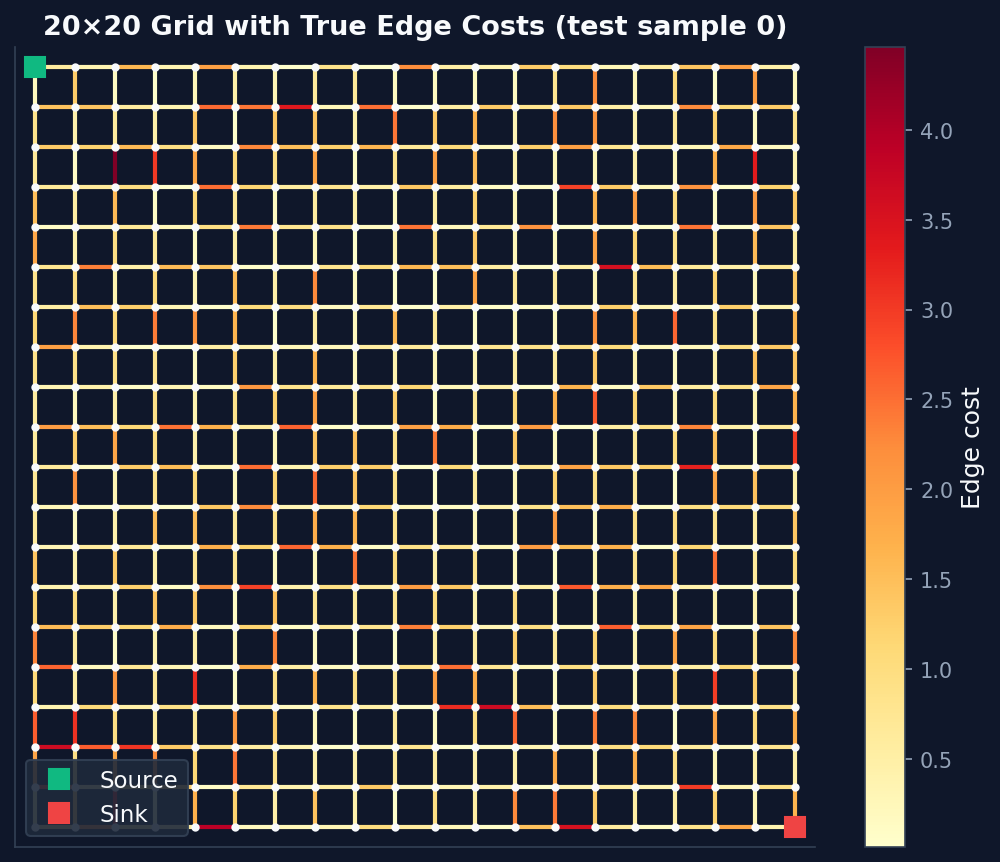

In [2]:
# --- Grid setup ---
grid_size = 20
n_nodes = grid_size * grid_size  # 400

# Directed edges: right + down
edges = []
edge_coords = []  # (row1, col1, row2, col2) for visualization
for r in range(grid_size):
    for c in range(grid_size):
        node = r * grid_size + c
        if c + 1 < grid_size:  # right
            edges.append((node, node + 1))
            edge_coords.append((r, c, r, c + 1))
        if r + 1 < grid_size:  # down
            edges.append((node, (r + 1) * grid_size + c))
            edge_coords.append((r, c, r + 1, c))
n_edges = len(edges)
edge_coords = np.array(edge_coords)

print(f"Grid: {grid_size}x{grid_size}, Nodes: {n_nodes}, Edges: {n_edges}")
print(f"Right edges: {grid_size * (grid_size - 1)}, Down edges: {(grid_size - 1) * grid_size}")

# --- Data generation ---
# Each sample has a shared context vector. True edge costs are a nonlinear
# function of context — too complex for the prediction network to learn
# perfectly, creating a capacity bottleneck that E2E can exploit.
n_context = 20      # context features per sample
n_hidden_true = 40  # true model hidden dimension
noise_std = 0.1

rng = np.random.RandomState(42)
V_true = rng.randn(n_hidden_true, n_context).astype(np.float64) * 0.3
d_true = rng.randn(n_hidden_true).astype(np.float64) * 0.1
W_true = rng.randn(n_edges, n_hidden_true).astype(np.float64) * 0.3
b_true = rng.randn(n_edges).astype(np.float64) * 0.5

def generate_data(n_samples, rng):
    """Generate context features and true edge costs."""
    context = rng.randn(n_samples, n_context).astype(np.float64)
    # Two-layer nonlinear model: context -> tanh hidden -> per-edge costs
    hidden = np.tanh(context @ V_true.T + d_true)
    linear = hidden @ W_true.T + b_true
    costs = np.log1p(np.exp(linear)) + rng.randn(n_samples, n_edges) * noise_std
    costs = np.maximum(costs, 0.01)  # ensure positive
    return context, costs

n_train, n_test = 5000, 500
ctx_train, costs_train = generate_data(n_train, np.random.RandomState(42))
ctx_test, costs_test = generate_data(n_test, np.random.RandomState(123))
print(f"Train: {n_train}, Test: {n_test}")
print(f"Context dim: {n_context}, True model hidden dim: {n_hidden_true}")
print(f"Cost range: [{costs_train.min():.2f}, {costs_train.max():.2f}]")

# --- Visualize one example: grid with edges colored by true cost ---
set_moreau_dark_style()
fig, ax = plt.subplots(figsize=(7, 7))

sample_costs = costs_test[0]
norm = Normalize(vmin=sample_costs.min(), vmax=sample_costs.max())
cmap = plt.cm.YlOrRd

for e_idx in range(n_edges):
    r1, c1, r2, c2 = edge_coords[e_idx]
    color = cmap(norm(sample_costs[e_idx]))
    ax.plot([c1, c2], [r1, r2], color=color, linewidth=2, solid_capstyle='round')

for r in range(grid_size):
    for c in range(grid_size):
        ax.plot(c, r, 'o', color=MOREAU_COLORS['text'], markersize=3, zorder=5)

ax.plot(0, 0, 's', color=MOREAU_COLORS['success'], markersize=10, zorder=6, label='Source')
ax.plot(grid_size - 1, grid_size - 1, 's', color=MOREAU_COLORS['danger'], markersize=10,
        zorder=6, label='Sink')

ax.set_xlim(-0.5, grid_size - 0.5)
ax.set_ylim(grid_size - 0.5, -0.5)
ax.set_aspect('equal')
ax.set_title(f'{grid_size}×{grid_size} Grid with True Edge Costs (test sample 0)', fontsize=13)
ax.legend(loc='lower left', fontsize=11, frameon=True, facecolor='#1E293B', edgecolor='#334155', framealpha=0.9)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='Edge cost', shrink=0.8)
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()
set_moreau_style()

## Build the CvxpyLayer

We define the shortest-path LP as a parametric CVXPY problem and wrap it
with `CvxpyLayer` to get a batched, differentiable PyTorch layer backed by Moreau.

In [3]:
# --- Flow conservation matrix A_eq (n_nodes x n_edges) ---
# A_eq[i, e] = -1 if edge e leaves node i, +1 if edge e enters node i
rows, cols, vals = [], [], []
for e_idx, (src, dst) in enumerate(edges):
    rows.append(src); cols.append(e_idx); vals.append(-1.0)  # outflow
    rows.append(dst); cols.append(e_idx); vals.append(1.0)   # inflow

A_eq = sparse.csr_array((vals, (rows, cols)), shape=(n_nodes, n_edges), dtype=np.float64)

# Demand vector: -1 at source (top-left), +1 at sink (bottom-right)
demand = np.zeros(n_nodes, dtype=np.float64)
demand[0] = -1.0                      # source
demand[n_nodes - 1] = 1.0             # sink

# --- Parametric CVXPY problem ---
f = cp.Variable(n_edges, nonneg=True)
q_param = cp.Parameter(n_edges)
eps_reg = 1.0

objective = cp.Minimize(q_param @ f + (eps_reg / 2) * cp.sum_squares(f))
constraints = [A_eq @ f == demand]
prob = cp.Problem(objective, constraints)

# Wrap as differentiable PyTorch layer (solved by Moreau on GPU)
layer = CvxpyLayer(prob, parameters=[q_param], variables=[f], solver="MOREAU",
                    solver_args={"ipm_settings": moreau.IPMSettings(direct_solve_method="qdldl")})

batch_size = 256

print(f"Variables (n): {n_edges}")
print(f"Constraints: {n_nodes} equality + {n_edges} non-negativity")
print(f"Regularization eps: {eps_reg}")

# Test solve with random costs
q_test = torch.rand(batch_size, n_edges, dtype=torch.float64, device=device) + 0.1
sol_test, = layer(q_test)
A_eq_dense = torch.tensor(A_eq.toarray(), dtype=torch.float64)
resid = (A_eq_dense @ sol_test[0].cpu() - torch.tensor(demand)).abs().max().item()
print(f"\nTest batch solve: flow conservation residual = {resid:.2e}")

Variables (n): 760
Constraints: 400 equality + 760 non-negativity
Regularization eps: 1.0



Test batch solve: flow conservation residual = 1.30e-10


## Neural Network Architecture

An MLP maps the shared context vector to predicted costs for all 760 edges.
The hidden layer is a **bottleneck** — it can't represent the full
40-dimensional true cost manifold.

End-to-end training focuses capacity on **path-relevant** edges;
two-stage training spreads capacity uniformly across all edges.

In [4]:
class EdgePredictor(nn.Module):
    """MLP: context -> predicted cost for all edges."""
    def __init__(self, n_context, n_edges, hidden=60):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_context, hidden, dtype=torch.float64),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2, dtype=torch.float64),
            nn.ReLU(),
            nn.Linear(hidden // 2, n_edges, dtype=torch.float64),
        )

    def forward(self, x):
        # x: (batch, n_context)
        return F.softplus(self.net(x))  # (batch, n_edges), positive


class ShortestPathLayer(nn.Module):
    """Neural net + CvxpyLayer as a differentiable shortest-path solver."""
    def __init__(self, n_context, n_edges, cvxpy_layer):
        super().__init__()
        self.predictor = EdgePredictor(n_context, n_edges)
        self.cvxpy_layer = cvxpy_layer

    def forward(self, context):
        # context: (batch, n_context)
        q_pred = self.predictor(context)  # (batch, n_edges)
        flows, = self.cvxpy_layer(q_pred)
        return flows, q_pred  # flows and predicted costs


model_e2e = ShortestPathLayer(n_context, n_edges, layer).to(device)
n_params = sum(p.numel() for p in model_e2e.parameters())
print(f"Parameters: {n_params:,}")
print(f"Architecture: {n_context} -> 60 -> 30 -> {n_edges}")
print(f"Bottleneck: 30 hidden units -> {n_edges} edge costs")

Parameters: 26,650
Architecture: 20 -> 60 -> 30 -> 760
Bottleneck: 30 hidden units -> 760 edge costs


## Training: End-to-End vs Two-Stage

- **End-to-end**: minimize actual path cost $c_{\text{true}}^\top f^*$ — gradients flow through Moreau
- **Two-stage**: minimize prediction error $\|q_\theta - c_{\text{true}}\|^2$, then plug into LP

In [5]:
def train_model(model, contexts, costs, n_epochs, mode='e2e', lr=1e-3,
                snapshot_interval=10, snap_ctx=None, snap_costs=None):
    """Train model with batched GPU solves."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n_samples = len(contexts)
    task_losses = []
    snapshots = []  # (epoch, flows) for animation

    ctx_t = torch.tensor(contexts, dtype=torch.float64, device=device)
    cost_t = torch.tensor(costs, dtype=torch.float64, device=device)

    if snap_ctx is not None:
        snap_ctx_t = torch.tensor(snap_ctx, dtype=torch.float64, device=device)

    for epoch in range(n_epochs):
        idx = torch.randint(0, n_samples, (batch_size,), device=device)
        ctx_batch = ctx_t[idx]     # (batch, n_context)
        cost_batch = cost_t[idx]   # (batch, n_edges)

        optimizer.zero_grad()
        flows, q_pred = model(ctx_batch)  # batched solve

        # Task loss: true cost of chosen path
        task_loss = (cost_batch * flows).sum(dim=1).mean()

        if mode == 'e2e':
            loss = task_loss
        else:
            loss = ((q_pred - cost_batch) ** 2).mean()

        loss.backward()
        optimizer.step()
        task_losses.append(task_loss.item())

        # Snapshot for animation
        if snap_ctx is not None and epoch % snapshot_interval == 0:
            with torch.no_grad():
                snap_flows, _ = model(snap_ctx_t.unsqueeze(0))
                snapshots.append((epoch, snap_flows[0].cpu().numpy()))

        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1:3d}: task_loss={task_loss.item():.4f}")

    return task_losses, snapshots


# Pick a fixed test sample for animation snapshots
snap_idx = 0
snap_ctx = ctx_test[snap_idx]
snap_costs = costs_test[snap_idx]

n_epochs = 500

# --- End-to-end ---
print("Training end-to-end model (backprop through CvxpyLayer)...")
model_e2e = ShortestPathLayer(n_context, n_edges, layer).to(device)
task_losses_e2e, snapshots_e2e = train_model(
    model_e2e, ctx_train, costs_train, n_epochs, mode='e2e',
    snap_ctx=snap_ctx, snap_costs=snap_costs,
)

# --- Two-stage ---
print("\nTraining two-stage model (MSE prediction loss)...")
model_2s = ShortestPathLayer(n_context, n_edges, layer).to(device)
task_losses_2s, _ = train_model(
    model_2s, ctx_train, costs_train, n_epochs, mode='two-stage',
)

Training end-to-end model (backprop through CvxpyLayer)...


/home/steven/repos/moreau-examples/.venv/lib/python3.12/site-packages/moreau/torch/__init__.py:98: UserWarning: Batch size has changed 5 times. Frequent batch size changes are slow because the CUDA solver must be recreated. Consider using a fixed batch size or padding batches to a consistent size.
  result = solver._impl.solve(q, b, **warm_kwargs)


  Epoch 100: task_loss=23.5981


  Epoch 200: task_loss=19.5467


  Epoch 300: task_loss=18.2066


...

  Epoch 100: task_loss=24.8610


  Epoch 200: task_loss=19.9917


  Epoch 300: task_loss=19.1938


  Epoch 400: task_loss=18.9320


  Epoch 500: task_loss=18.6304


## Results

In [6]:
# --- Evaluate on test set ---
def evaluate_on_test(model, contexts, costs):
    """Compute per-sample path cost on test set."""
    n = len(contexts)
    all_flows = []
    all_path_costs = []

    ctx_t_eval = torch.tensor(contexts, dtype=torch.float64, device=device)
    cost_t_eval = torch.tensor(costs, dtype=torch.float64, device=device)

    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            flows, _ = model(ctx_t_eval[start:end])
            pc = (cost_t_eval[start:end] * flows).sum(dim=1)
            all_flows.append(flows.cpu().numpy())
            all_path_costs.append(pc.cpu().numpy())

    return np.concatenate(all_flows), np.concatenate(all_path_costs)


# Exact solver (eps=1e-4) for computing true shortest paths.
# The training layer uses eps=1.0 for smooth gradients, but the "optimal"
# reference should be the actual shortest path (eps -> 0).
f_exact = cp.Variable(n_edges, nonneg=True)
q_exact_param = cp.Parameter(n_edges)
eps_exact = 1e-4

obj_exact = cp.Minimize(q_exact_param @ f_exact + (eps_exact / 2) * cp.sum_squares(f_exact))
prob_exact = cp.Problem(obj_exact, [A_eq @ f_exact == demand])
layer_exact = CvxpyLayer(prob_exact, parameters=[q_exact_param], variables=[f_exact],
                          solver="MOREAU",
                          solver_args={"ipm_settings": moreau.IPMSettings(direct_solve_method="qdldl")})


def compute_optimal(costs):
    """Solve true shortest path (eps=1e-4) with true costs."""
    n = len(costs)
    all_flows = []
    all_path_costs = []
    cost_t_local = torch.tensor(costs, dtype=torch.float64, device=device)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        flows, = layer_exact(cost_t_local[start:end])
        pc = (cost_t_local[start:end] * flows).sum(dim=1)
        all_flows.append(flows.cpu().detach().numpy())
        all_path_costs.append(pc.cpu().detach().numpy())

    return np.concatenate(all_flows), np.concatenate(all_path_costs)


print("Computing optimal paths (true costs, eps=1e-4)...")
opt_flows, opt_costs = compute_optimal(costs_test)

print("Evaluating end-to-end model...")
flows_e2e, pcosts_e2e = evaluate_on_test(model_e2e, ctx_test, costs_test)

print("Evaluating two-stage model...")
flows_2s, pcosts_2s = evaluate_on_test(model_2s, ctx_test, costs_test)

# Regret = actual path cost - true optimal path cost
regret_e2e = pcosts_e2e - opt_costs
regret_2s = pcosts_2s - opt_costs

# Uniform-cost baseline
uniform_q = torch.ones(1, n_edges, dtype=torch.float64, device=device)
with torch.no_grad():
    uniform_flow, = layer(uniform_q)
    uniform_flow = uniform_flow[0].cpu().numpy()
pcosts_uniform = np.array([(costs_test[i] * uniform_flow).sum() for i in range(n_test)])
regret_uniform = pcosts_uniform - opt_costs

print(f"\nMean test regret (path cost - true optimal):")
print(f"  Uniform cost:  {regret_uniform.mean():.4f}")
print(f"  Two-stage:     {regret_2s.mean():.4f}")
print(f"  End-to-end:    {regret_e2e.mean():.4f}")
improvement = (1 - regret_e2e.mean() / regret_2s.mean()) * 100
print(f"\nE2E improvement over two-stage: {improvement:.0f}% lower regret")

Computing optimal paths (true costs, eps=1e-4)...


Evaluating end-to-end model...


Evaluating two-stage model...



Mean test regret (path cost - true optimal):
  Uniform cost:  19.5232
  Two-stage:     3.9553
  End-to-end:    2.8417

E2E improvement over two-stage: 28% lower regret


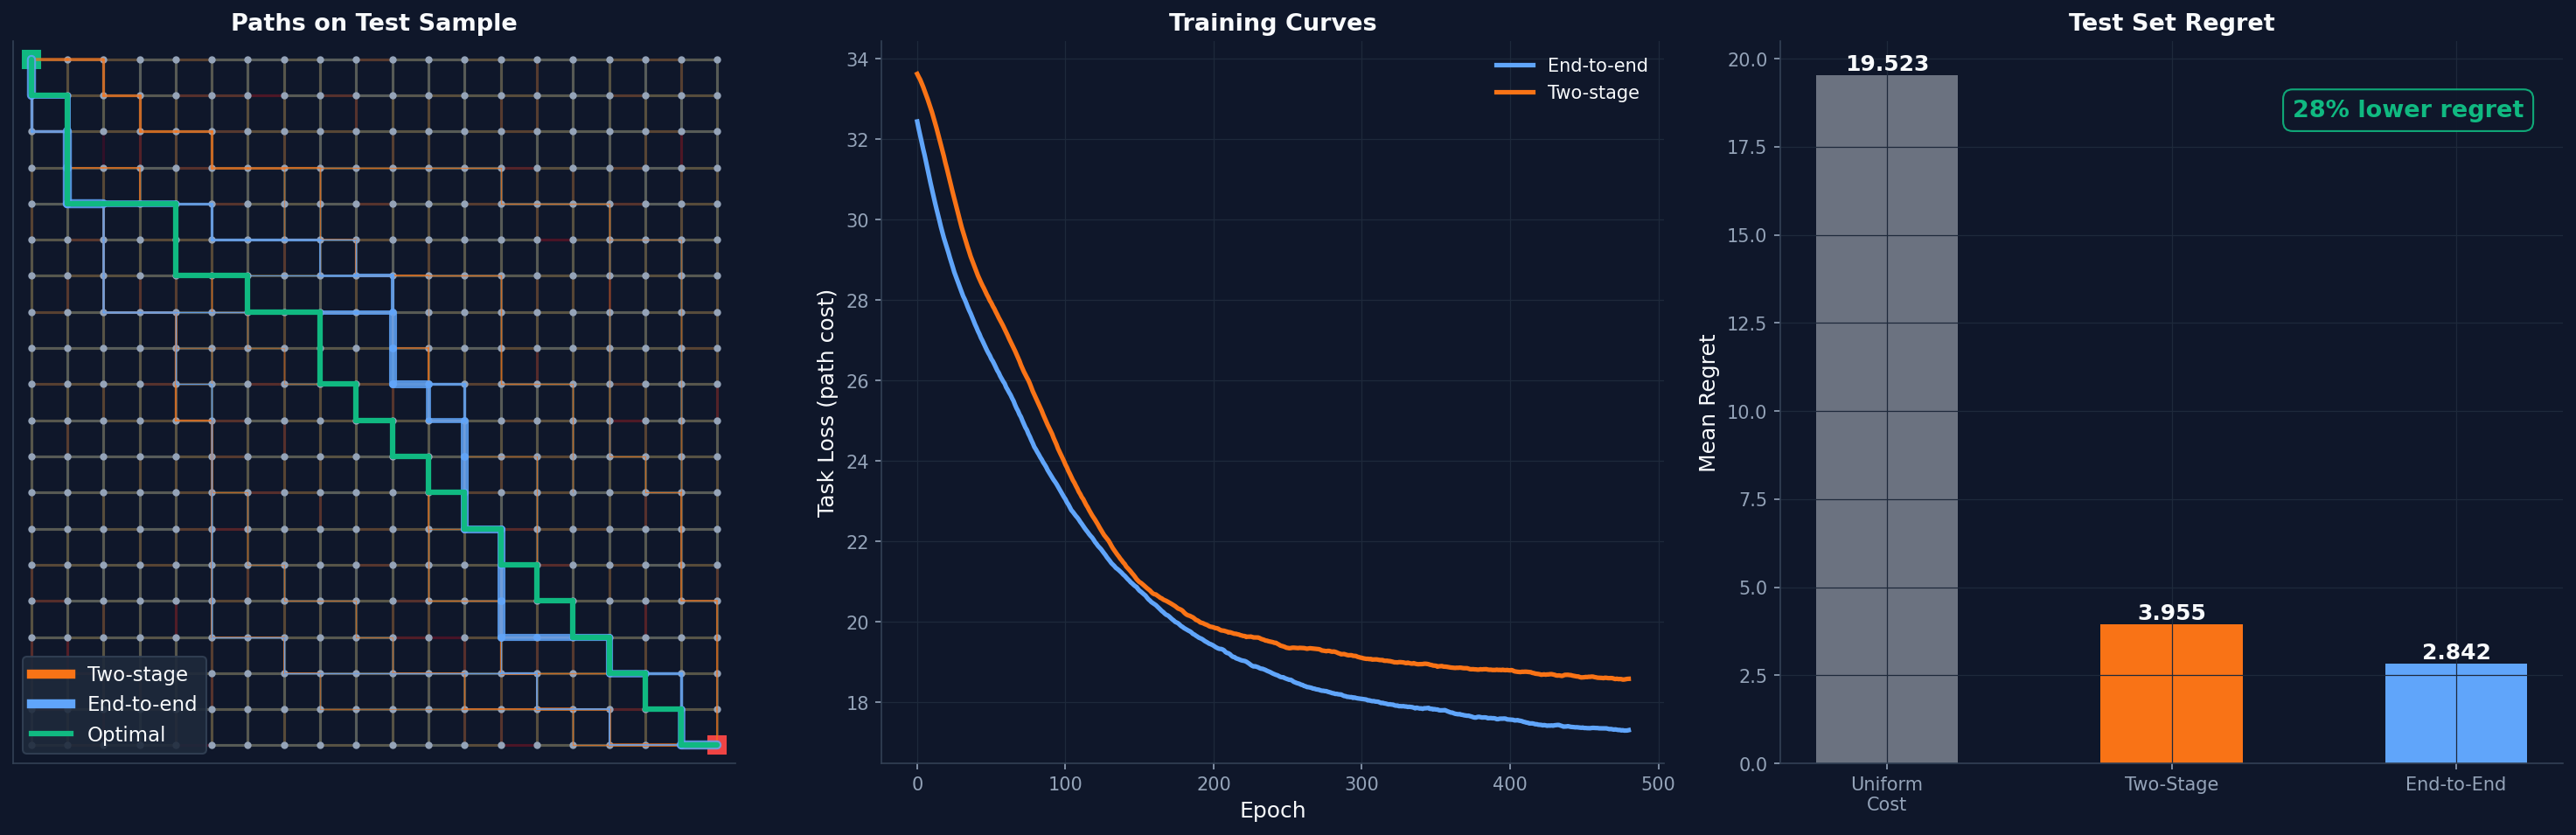

In [7]:
# --- Helper: draw a path on a grid ---
def draw_grid_path(ax, flows, color, label, linewidth=3, alpha=0.9):
    """Draw edges with flow > threshold as a path on the grid."""
    threshold = 0.05
    for e_idx in range(n_edges):
        if flows[e_idx] > threshold:
            r1, c1, r2, c2 = edge_coords[e_idx]
            lw = linewidth * min(flows[e_idx], 1.0)
            ax.plot([c1, c2], [r1, r2], color=color, linewidth=lw,
                    solid_capstyle='round', alpha=alpha, zorder=10)
    ax.plot([], [], color=color, linewidth=linewidth, label=label)


def draw_grid_background(ax, costs, cmap=plt.cm.YlOrRd):
    """Draw the grid with edges colored by true cost."""
    norm = Normalize(vmin=costs.min(), vmax=costs.max())
    for e_idx in range(n_edges):
        r1, c1, r2, c2 = edge_coords[e_idx]
        color = cmap(norm(costs[e_idx]))
        ax.plot([c1, c2], [r1, r2], color=color, linewidth=1.5,
                solid_capstyle='round', alpha=0.3)
    for r in range(grid_size):
        for c in range(grid_size):
            ax.plot(c, r, 'o', color=MOREAU_COLORS['text_secondary'],
                    markersize=3, zorder=4)
    ax.plot(0, 0, 's', color=MOREAU_COLORS['success'], markersize=10, zorder=6)
    ax.plot(grid_size - 1, grid_size - 1, 's', color=MOREAU_COLORS['danger'],
            markersize=10, zorder=6)


# --- 3-panel figure ---
set_moreau_dark_style()
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))

# Panel 1: Grid paths comparison
ax = axes[0]
draw_grid_background(ax, snap_costs)
draw_grid_path(ax, flows_2s[snap_idx], MOREAU_COLORS['accent'], 'Two-stage',
               linewidth=5, alpha=0.7)
draw_grid_path(ax, flows_e2e[snap_idx], MOREAU_COLORS['primary_light'], 'End-to-end',
               linewidth=5, alpha=0.85)
draw_grid_path(ax, opt_flows[snap_idx], MOREAU_COLORS['success'], 'Optimal',
               linewidth=3, alpha=1.0)
ax.set_xlim(-0.5, grid_size - 0.5)
ax.set_ylim(grid_size - 0.5, -0.5)
ax.set_aspect('equal')
ax.set_title('Paths on Test Sample', fontsize=13)
ax.legend(loc='lower left', fontsize=11, frameon=True, facecolor='#1E293B', edgecolor='#334155', framealpha=0.9)
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])

# Panel 2: Training curves (task loss)
ax = axes[1]
window = 20
def smooth(x, w):
    return np.convolve(x, np.ones(w)/w, mode='valid')

ax.plot(smooth(task_losses_e2e, window), color=MOREAU_COLORS['primary_light'],
        label='End-to-end', linewidth=2.5)
ax.plot(smooth(task_losses_2s, window), color=MOREAU_COLORS['accent'],
        label='Two-stage', linewidth=2.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Task Loss (path cost)')
ax.set_title('Training Curves', fontsize=13)
ax.legend(fontsize=10)

# Panel 3: Regret bar chart
ax = axes[2]
methods = ['Uniform\nCost', 'Two-Stage', 'End-to-End']
regrets = [regret_uniform.mean(), regret_2s.mean(), regret_e2e.mean()]
bar_colors = [MOREAU_COLORS['neutral'], MOREAU_COLORS['accent'], MOREAU_COLORS['primary_light']]
bars = ax.bar(methods, regrets, color=bar_colors, width=0.5, edgecolor='none')
ax.set_ylabel('Mean Regret')
ax.set_title('Test Set Regret', fontsize=13)
for bar, reg in zip(bars, regrets):
    y_pos = max(reg, 0) + 0.01
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            f'{reg:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12,
            color=MOREAU_COLORS['text'])

# Improvement badge
if regret_2s.mean() > 0 and regret_e2e.mean() < regret_2s.mean():
    pct = (1 - regret_e2e.mean() / regret_2s.mean()) * 100
    ax.annotate(
        f'{pct:.0f}% lower regret',
        xy=(0.95, 0.92), xycoords='axes fraction',
        ha='right', va='top', fontsize=13, fontweight='bold',
        color=MOREAU_COLORS['success'],
        bbox=dict(boxstyle='round,pad=0.4', facecolor=MOREAU_COLORS['bg_dark'],
                  edgecolor=MOREAU_COLORS['success'], alpha=0.9),
    )

plt.tight_layout()
plt.savefig('../assets/predict_then_optimize.png', bbox_inches='tight',
            facecolor=MOREAU_COLORS['bg_dark'])
plt.show()
set_moreau_style()

## Training Animation

Watch the end-to-end model's path converge to the optimal route over training.

Saved 50-frame animation to ../assets/predict_then_optimize_anim.gif



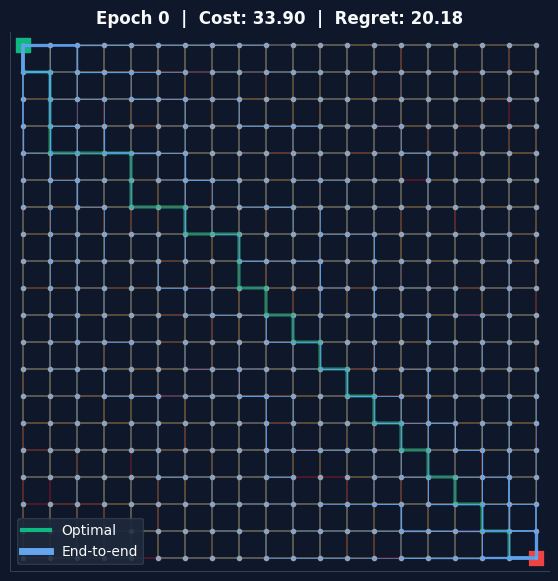

In [8]:
set_moreau_dark_style()

opt_snap_flows = opt_flows[snap_idx]
opt_snap_cost = opt_costs[snap_idx]

frames = []
for epoch, snap_flows in snapshots_e2e:
    fig, ax = plt.subplots(figsize=(7, 7))
    draw_grid_background(ax, snap_costs)

    # Optimal path (faint)
    draw_grid_path(ax, opt_snap_flows, MOREAU_COLORS['success'], 'Optimal',
                   linewidth=3, alpha=0.4)
    # Current E2E path
    draw_grid_path(ax, snap_flows, MOREAU_COLORS['primary_light'], 'End-to-end',
                   linewidth=5, alpha=0.9)

    path_cost = (snap_costs * snap_flows).sum()
    regret = path_cost - opt_snap_cost

    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(grid_size - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_title(f'Epoch {epoch}  |  Cost: {path_cost:.2f}  |  Regret: {regret:.2f}',
                 fontsize=12)
    ax.legend(loc='lower left', fontsize=10, frameon=True, facecolor='#1E293B', edgecolor='#334155', framealpha=0.9)
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

    frames.append(fig_to_pil(fig))
    plt.close(fig)

gif_path = '../assets/predict_then_optimize_anim.gif'
save_gif(frames, gif_path, fps=8)
print(f"Saved {len(frames)}-frame animation to {gif_path}")
display_gif(gif_path)

## Gradient Flow Through the Solver

**Forward:**
$$\xi \;\xrightarrow{f_\theta}\; \hat{q} \;\xrightarrow{\text{solve LP}}\; f^*(\hat{q}) \;\rightarrow\; \mathcal{L} = c^\top f^*$$

**Backward:**
$$\frac{\partial \mathcal{L}}{\partial \theta} \;=\; \underbrace{\frac{\partial f^*}{\partial \hat{q}}}_{\text{KKT implicit diff}} \cdot \frac{\partial \hat{q}}{\partial \theta}$$

Moreau computes $\frac{\partial f^*}{\partial q}$ via implicit differentiation of the KKT conditions,
not by unrolling solver iterations. This means:
- **Constant memory** — no need to store intermediate iterates
- **Exact gradients** — not approximate
- **Fast** — one linear system solve for the backward pass

---

**Key takeaways:**
- `cvxpylayers` wraps a CVXPY problem as a **batched, differentiable** PyTorch layer, backed by Moreau on GPU
- End-to-end training focuses network capacity on **decision-relevant** edges, achieving lower regret
- Two-stage training wastes capacity predicting costs of edges that are never on the optimal path
- Implicit differentiation through KKT conditions gives **exact, memory-efficient gradients**
- Batched solving (256 LPs per step) makes training practical — no Python for-loops over samples